# WINS50 Offshore Wind — Initial Data Exploration

**Author:** Noah · **Group 3** · Data Science (THUAS)
**Data source:** [WINS50](https://www.wins50.nl/data/) — KNMI/Whiffle HARMONIE-AROME wind-farm power-production simulations for the North Sea.

This notebook explores the **WINS50 offshore power-production** dataset and connects it to two backlog items:
- **PB1-6** (sum offshore vs total power) — we build a national NL offshore aggregate timeseries here.
- **PB1-7** (compare power curves) — we build the farm→weather-grid mapping needed to join wind speed to power (the wind speed itself comes from the HARMONIE NetCDF files via the KNMI API; documented at the end).

> This is a **new** data source — distinct from the Kaggle offshore set in `initial_data_exploration_offshore.ipynb`.

## 0. What the raw data looks like (read this first)

**Power files** (`wins50_harmonie_windfarm_powerproduction.zip`): one CSV per wind farm, 161 farms across the whole North Sea, hourly for all of 2020. Columns:
- `DateTime` — format `YYYYMMDDHH` (e.g. `2020010100`).
- `Power W20 [MW]` — the **2020 operational** scenario (farms actually running on 1 Jan 2020).
- `Power W50 [MW]` — the hypothetical **2050** scenario (full build-out, ~53 GW in NL waters).

**Two gotchas to remember:**
1. A farm that wasn't operational in 2020 has **`nan` in the W20 column** and only carries W50 values (e.g. Borssele, Hollandse Kust). That's correct, not missing data.
2. Power is in **MW**; we'll convert big aggregates to GW/TWh for readability.

**Metadata files:**
- `wins50_windfarm_scenarios.shp` (+ `.dbf/.shx/.cpg`) — installed capacity (MW), turbine type, hub height, and the polygon footprint per farm.
- `wins50_singlepoint_lookuptable.csv` — maps each weather-grid index `(ix, iy)` to a lat/lon. Needed to find which grid cell sits on each farm (for PB1-7).

In [1]:
import zipfile, re
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- paths (relative to this notebook in initial_exploration/) ---
RAW = Path("../datasets_raw/WINS50")
OUT = Path("../datasets")
OUT.mkdir(exist_ok=True)

POWER_ZIP = RAW / "wins50_harmonie_windfarm_powerproduction.zip"
LOOKUP    = RAW / "wins50_singlepoint_lookuptable.csv"
SHAPE     = RAW / "wins50_windfarm_scenarios.shp"

def norm(s):
    """Normalise a farm name so power-file and shapefile names match
    (lowercase, drop spaces/punctuation). 'Borssele 1' -> 'borssele1'."""
    return re.sub(r'[^a-z0-9]', '', str(s).lower())

## 1. Build farm metadata: capacity + nearest weather grid cell

We read the shapefile (capacities live here, per scenario), collapse it to one row per farm, then attach the **nearest WINS50 grid cell** to each farm using the lookup table. This single table is the bridge between *power*, *capacity*, and the *weather grid* — and it's what PB1-7 needs to find wind speed at each farm.

In [2]:
g = gpd.read_file(SHAPE)
g["key"] = g["name"].map(norm)

def summarise(df):
    op  = df[df["Scenario"].isin([2019, 2020, 2021])]   # operational layers
    f50 = df[df["Scenario"] == 2050]                     # 2050 build-out
    c   = df.geometry.union_all().centroid               # farm centre point
    big = df.sort_values("MW").iloc[-1]                  # largest build-out row
    return pd.Series({
        "farm": df["name"].iloc[0], "country": df["country"].iloc[0],
        "cap_op_MW":   op["MW"].max()  if len(op)  else np.nan,   # operational nameplate
        "cap_2050_MW": df["MW"].max(),   # full build-out = largest layer (2050 includes earlier farms)
        "turb_type": big["Turb_type"], "hub_z_m": big["z"],
        "lat": round(c.y, 4), "lon": round(c.x, 4),
    })

meta = g.groupby("key").apply(summarise, include_groups=False).reset_index()

# nearest weather grid cell for every farm
lut = pd.read_csv(LOOKUP)
LAT, LON, IX, IY = lut.lat.values, lut.lon.values, lut.ix.values, lut.iy.values
def nearest_gridpoint(lat, lon):
    # squared distance with a cos(lat) correction so degrees of lon are scaled right
    d = (LAT - lat)**2 + ((LON - lon) * np.cos(np.radians(lat)))**2
    j = d.argmin()
    return IX[j], IY[j], round(LAT[j], 4), round(LON[j], 4)

meta[["grid_ix", "grid_iy", "grid_lat", "grid_lon"]] = [
    nearest_gridpoint(r.lat, r.lon) for r in meta.itertuples()
]

# keep only farms that actually have power timeseries
zf = zipfile.ZipFile(POWER_ZIP)
power_files = {norm(n.split("powerproduction_")[1][:-4]): n
               for n in zf.namelist() if n.endswith(".csv")}
meta = meta[meta.key.isin(power_files)].sort_values(["country", "farm"]).reset_index(drop=True)

meta.to_csv(OUT / "wins50_farm_metadata.csv", index=False)
print(f"{len(meta)} farms  |  {(meta.country=='NL').sum()} in NL")
meta[meta.country == "NL"][["farm","cap_op_MW","cap_2050_MW","turb_type","grid_ix","grid_iy"]].head(12)

161 farms  |  37 in NL


,farm,cap_op_MW,cap_2050_MW,turb_type,grid_ix,grid_iy
101,Amalia,120.0,120.0,V80_ECN,78.0,100.0
102,Borssele 1,360.0,360.0,REF-8.0,48.0,61.0
103,Borssele 2,376.0,376.0,REF-8.0,49.0,56.0
104,Borssele 3,396.0,396.0,V164-8.0,46.0,58.0
105,Borssele 4,320.0,320.0,V164-8.0,43.0,61.0
106,Fryslan,NaN,356.0,SWT-4.0-130,105.0,121.0
107,Future_122,NaN,3885.0,IEA15,77.0,211.0
108,Future_123,NaN,4170.0,IEA15,54.0,196.0
109,Future_124,NaN,3510.0,IEA15,44.0,183.0
110,Future_125,NaN,4965.0,IEA15,53.0,143.0


## 2. Load the power timeseries (focus on NL)

The project is about the **Netherlands**, so we load only the NL farms. We reshape into one tidy ('long') table: one row per farm per hour.

In [3]:
nl = meta[meta.country == "NL"].copy()

frames = []
for k in nl.key:
    d = pd.read_csv(zf.open(power_files[k]))
    d.columns = ["dt", "P_op_MW", "P_2050_MW"]   # operational(2020), 2050
    d["key"] = k
    frames.append(d)

power = pd.concat(frames, ignore_index=True)
power["dt"] = pd.to_datetime(power["dt"], format="%Y%m%d%H")   # parse YYYYMMDDHH

print("rows:", len(power), "| span:", power.dt.min().date(), "→", power.dt.max().date())
print("hours per farm:", power.groupby('key').size().iloc[0], "(2020 is a leap year → 8784h)")
power.head()

rows: 325008 | span: 2020-01-01 → 2020-12-31
hours per farm: 8784 (2020 is a leap year → 8784h)


,dt,P_op_MW,P_2050_MW,key
0,2020-01-01 00:00:00,14.699198,15.072088,amalia
1,2020-01-01 01:00:00,20.917976,20.365486,amalia
2,2020-01-01 02:00:00,19.318544,18.289974,amalia
3,2020-01-01 03:00:00,20.082991,18.211912,amalia
4,2020-01-01 04:00:00,22.625584,19.852421,amalia


## 2b. Data quality checks

WINS50 power is **simulated model output**, not raw sensor data, so the job here is to *validate* it, not scrub spikes/gaps like real SCADA. Findings:

- **Complete time axis** — 8784 hourly steps per farm (2020 is a leap year), no duplicates, no gaps.
- **No negative power.**
- **W20 (2020) is ~86% NaN** — the farms not operational in 2020. Intentional; kept as NaN, and we aggregate with `min_count=1` so they never become fake zeros.
- **Power can sit a few % above nameplate** (per-farm peaks cluster ~104%). Expected: power depends on wind speed *and air density*, and cold dense offshore air pushes output past the standard-density rating. We do **not** clip it. One farm (Borssele 4) peaks ~120% — a minor capacity-attribute mismatch, immaterial to aggregates.

> **Important for PB1-6:** WINS50 timestamps are **UTC**; ENTSO-E is usually local/CET. Align timezones before joining, or the correlation shifts by 1-2 hours.

In [4]:
gp = power.groupby("key")
full_year = pd.date_range("2020-01-01", "2020-12-31 23:00", freq="h")   # 8784h
checks = {
    "farms": power.key.nunique(),
    "hours/farm (min, max)": (int(gp.size().min()), int(gp.size().max())),
    "duplicate-timestamp farms": int((gp.dt.nunique() != gp.size()).sum()),
    "missing hours (max/farm)": int(gp.dt.apply(lambda s: (~full_year.isin(s)).sum()).max()),
    "negative power (W20, W50)": (int((power.P_op_MW < 0).sum()), int((power.P_2050_MW < 0).sum())),
    "W20 NaN share": f"{power.P_op_MW.isna().mean():.0%} (not built by 2020 - intentional)",
}
for k, v in checks.items():
    print(f"{k:28s}: {v}")

over = power.join(nl.set_index("key")["cap_2050_MW"], on="key")
over = over.P_2050_MW / over.cap_2050_MW
print(f"\nmax hourly power / nameplate: {over.max():.2f}  (expected slightly >1 from air density)")

farms                       : 37
hours/farm (min, max)       : (8784, 8784)
duplicate-timestamp farms   : 0
missing hours (max/farm)    : 0
negative power (W20, W50)   : (0, 0)
W20 NaN share               : 86% (not built by 2020 - intentional)

max hourly power / nameplate: 1.20  (expected slightly >1 from air density)


## 3. Capacity factor per farm (2050 scenario)

**Capacity factor (CF)** = average power ÷ installed capacity. It tells you how productive a farm is regardless of size. We use the 2050 scenario because every farm has it. Offshore NL should land around **45–55%** — a good sanity check on the whole join.

NL capacity factor (2050): mean 47.5%   range 35.9–55.3%


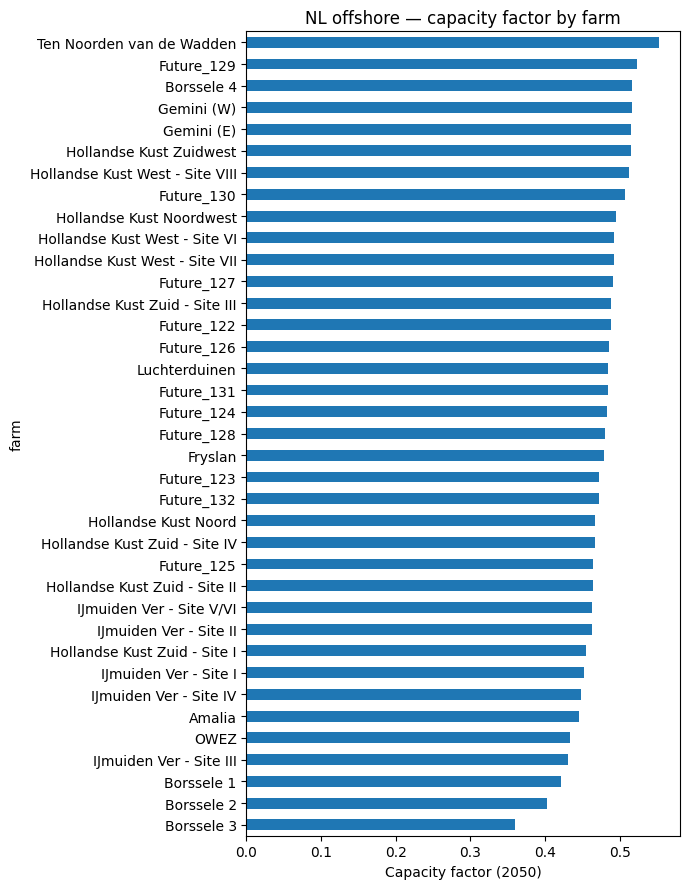

In [5]:
cf = (power.groupby("key").P_2050_MW.mean().to_frame("mean_MW")
        .join(nl.set_index("key")[["farm", "cap_2050_MW"]]))
cf["CF_2050"] = cf.mean_MW / cf.cap_2050_MW

print("NL capacity factor (2050): mean %.1f%%   range %.1f–%.1f%%"
      % (cf.CF_2050.mean()*100, cf.CF_2050.min()*100, cf.CF_2050.max()*100))

ax = cf.sort_values("CF_2050").plot.barh(x="farm", y="CF_2050", figsize=(7,9), legend=False)
ax.set_xlabel("Capacity factor (2050)"); ax.set_title("NL offshore — capacity factor by farm")
plt.tight_layout(); plt.show()

## 4. National offshore aggregate  →  feeds PB1-6

Sum power across all NL farms at each hour to get one national offshore production curve. This is exactly the series PB1-6 compares against ENTSO-E's total power. We save it to `datasets/` for the rest of the team.

NL aggregate mean output:  2020-operational 0.50 GW  |  2050 25.50 GW
2050 total annual energy:  224 TWh


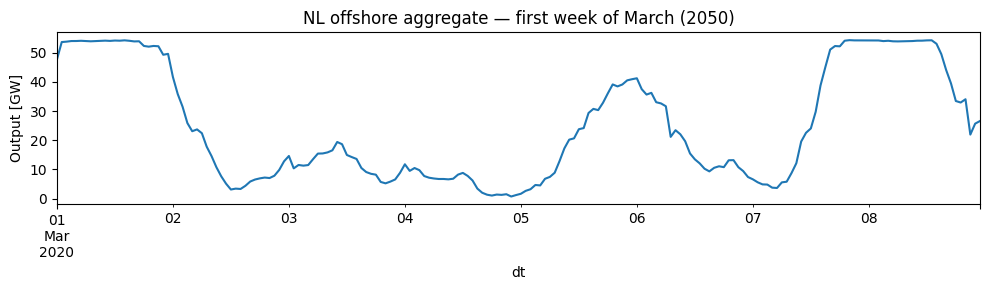

In [6]:
agg = power.groupby("dt")[["P_op_MW", "P_2050_MW"]].sum(min_count=1)

print("NL aggregate mean output:  2020-operational %.2f GW  |  2050 %.2f GW"
      % (agg.P_op_MW.mean()/1000, agg.P_2050_MW.mean()/1000))
print("2050 total annual energy:  %.0f TWh" % (agg.P_2050_MW.sum()/1e6))

agg.reset_index().to_csv(OUT / "wins50_nl_offshore_aggregate.csv", index=False)

# one week of 2050 output, to see the intermittency
agg.P_2050_MW.loc["2020-03-01":"2020-03-08"].div(1000).plot(figsize=(10,3))
plt.ylabel("Output [GW]"); plt.title("NL offshore aggregate — first week of March (2050)")
plt.tight_layout(); plt.show()

## 5. Seasonality and the output distribution

Two classic wind checks: (a) wind is stronger in winter, so monthly mean output should peak Dec–Feb; (b) the distribution of capacity factor is **not** bell-shaped — it piles up at low output (calm) and again near rated power (windy).

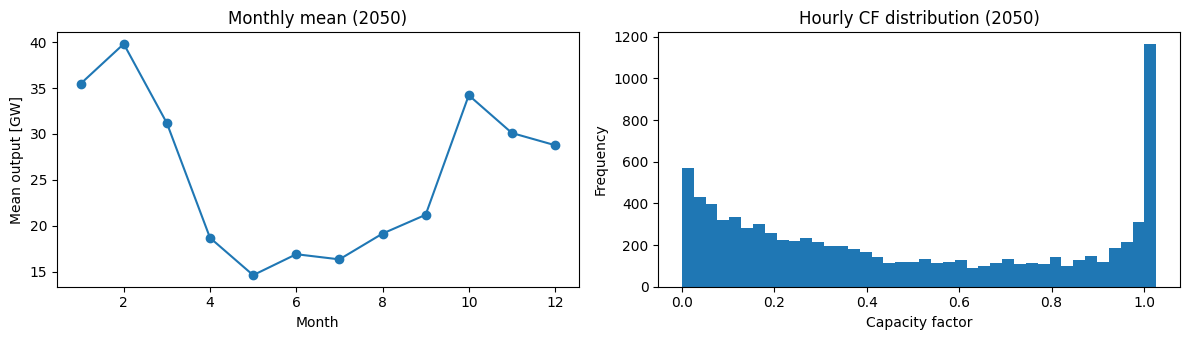

winter (Dec/Jan): 28.8 / 35.5 GW   vs   summer (Jul/Aug): 16.3 / 19.1 GW


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

monthly = agg.P_2050_MW.groupby(agg.index.month).mean() / 1000
monthly.plot(marker="o", ax=ax[0]); ax[0].set_xlabel("Month"); ax[0].set_ylabel("Mean output [GW]")
ax[0].set_title("Monthly mean (2050)")

(agg.P_2050_MW / nl.cap_2050_MW.sum()).plot.hist(bins=40, ax=ax[1])
ax[1].set_xlabel("Capacity factor"); ax[1].set_title("Hourly CF distribution (2050)")
plt.tight_layout(); plt.show()

print("winter (Dec/Jan): %.1f / %.1f GW   vs   summer (Jul/Aug): %.1f / %.1f GW"
      % (monthly[12], monthly[1], monthly[7], monthly[8]))

## 6. 2020 vs 2050 — the scale-up

How much does Dutch offshore production grow from today's build-out to the 2050 scenario?

In [8]:
print("Installed capacity:  operational %.1f GW  →  2050 %.1f GW  (%.0fx)"
      % (nl.cap_op_MW.sum()/1000, nl.cap_2050_MW.sum()/1000,
         nl.cap_2050_MW.sum()/nl.cap_op_MW.sum()))
print("Mean output:         operational %.2f GW  →  2050 %.2f GW"
      % (agg.P_op_MW.mean()/1000, agg.P_2050_MW.mean()/1000))
# NOTE: only ~9 NL farms have operational (W20) data — see gotcha #1 at the top.
print("Farms with operational data:", int(power.groupby('key').P_op_MW.apply(lambda s: s.notna().any()).sum()),
      "of", power.key.nunique())

Installed capacity:  operational 2.4 GW  →  2050 53.2 GW  (22x)
Mean output:         operational 0.50 GW  →  2050 25.50 GW
Farms with operational data: 5 of 37


## 7. Next step for PB1-7: wind speed via the KNMI API (roadmap)

To build the **power curve** (wind speed → power) we need wind speed at each farm. That lives in the HARMONIE **NetCDF** files on the KNMI Data Platform, which need a free **Open Data API** key (register at https://developer.dataplatform.knmi.nl/).

The flow, using the farm→grid mapping we built in section 1:
1. For a farm, read its `grid_ix`, `grid_iy` from `wins50_farm_metadata.csv`.
2. Download that grid cell's **time-series** NetCDF (small — one location, all heights) via the API.
3. Open with `xarray`, take wind speed at hub height (~100–150 m), resample to hourly.
4. Join to this notebook's power series on the timestamp → bin by wind speed → that's the power curve.

The skeleton below is **not run** (needs your API key + the dataset name/version from the WINS50 example script `wins50_pull_from_knmi_kdp.py`).

In [9]:
# ROADMAP — do not run until you have an Open Data API key in a .env file.
#
# import os, requests, xarray as xr
# from dotenv import load_dotenv; load_dotenv()
#
# API_KEY = os.environ["KNMI_API_KEY"]
# BASE    = "https://api.dataplatform.knmi.nl/open-data/v1"
# DATASET = "<wins50 timeseries dataset name>"   # from wins50_pull_from_knmi_kdp.py / KNMI catalog
# VERSION = "<version>"
# headers = {"Authorization": API_KEY}
#
# # 1. pick a farm's grid cell
# row = meta.loc[meta.farm == "Borssele 1"].iloc[0]
# ix, iy = int(row.grid_ix), int(row.grid_iy)
#
# # 2. find the matching singlepoint filename, request a temporary download URL, download
# files = requests.get(f"{BASE}/datasets/{DATASET}/versions/{VERSION}/files",
#                       headers=headers, params={"maxKeys": 1000}).json()["files"]
# fname = next(f["filename"] for f in files if f"{ix}_{iy}" in f["filename"])   # match on grid index
# url = requests.get(f"{BASE}/datasets/{DATASET}/versions/{VERSION}/files/{fname}/url",
#                    headers=headers).json()["temporaryDownloadUrl"]
# open(fname, "wb").write(requests.get(url).content)
#
# # 3. read wind speed, 4. join to power → power curve
# ds = xr.open_dataset(fname)
# # ws = ds["wspeed"].sel(height=100).to_series()  # exact var/coord names: inspect ds first
print("Roadmap cell — see markdown above.")

Roadmap cell — see markdown above.


## Summary of findings

- **47.5%** mean capacity factor for NL offshore (2050 scenario), range 36–55% — consistent with real-world North Sea offshore.
- NL offshore scales from **~2.4 GW → ~53 GW** installed (matching the official WINS50 2050 target ✅), lifting mean output from ~0.5 GW to ~25 GW and yielding **~224 TWh/year**.
- Strong **winter > summer** seasonality (≈2×) and a non-Gaussian, piled-at-the-ends output distribution — both textbook wind behaviour.
- Built `wins50_farm_metadata.csv` (capacity + nearest weather grid cell per farm) and `wins50_nl_offshore_aggregate.csv` (national hourly series for PB1-6).

**Outputs written to `datasets/`:** `wins50_farm_metadata.csv`, `wins50_nl_offshore_aggregate.csv`.